In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import chess
import chess.svg
import random
import time
import math
import csv
from tqdm import tqdm
from pathlib import Path
from IPython.display import display, SVG

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 512
MODEL_DIR = Path("models")
LOGS_DIR = Path("experiments/logs")

# linear_probe: No negative sample, linear_probe_v2: include negative sample and TSP

In [2]:
if torch.cuda.is_available():
    device = "cuda" 
    print("CUDA version:", torch.version.cuda)
    print("GPU:", torch.cuda.get_device_name())
else:
    device = "cpu"
    
device

CUDA version: 12.9
GPU: NVIDIA GeForce RTX 3070


'cuda'

In [2]:
# ==========================================
# Configuration
# ==========================================
class Config:
    # Models to train in this run, eg. ACTIVE_PROBES = ["TRANSFORMER", "CNN", "MLP"]
    ACTIVE_PROBES = ["TRANSFORMER", "CNN", "MLP"]
    # chess.BISHOP, chess.ROOK, chess.QUEEN
    PROBE_PIECES = [chess.KNIGHT, chess.BISHOP, chess.ROOK, chess.QUEEN] 
    
    # Control the BCE Loss positive weight for class imbalance
    PIECE_WEIGHTS = {
        chess.KNIGHT: 10.0,
        chess.BISHOP: 10.0,
        chess.ROOK: 6.0,
        chess.QUEEN: 4.0,
        # chess.PAWN: 2.0, 
        # chess.KING: 20.0 
    }

    # Training Hyperparameters
    EPOCHS = 10
    LEARNING_RATE = 1e-3
    
    # Inference / Visualization Settings
    TEST_FEN = "2r2r2/2p1qpk1/p1np3p/1p4p1/4P3/Q3N1bP/P2K2P1/2R2B2 w - - 0 1"
    TARGET_SQUARE = chess.parse_square("c1") # Set to None for a random piece

MODEL_REGISTRY = {
    "CNN": {
        "name": "seresnet_new_v2_16",
        "dataset_dir": Path("./dataset_planes_cp/"),
        "is_3d": True,
        "model_kwargs": {"in_channels": 19, "channels": 64, "num_blocks": 16, "num_classes": 7}
    },
    "MLP": {
        "name": "probs_mlp_v4",
        "dataset_dir": Path("./dataset_bitmaps_cp/"),
        "is_3d": False,
        "model_kwargs": {"input_shape": 775, "output_shape": 7}
    },
    "TRANSFORMER": {
        "name": "transformer_v1",
        "dataset_dir": Path("./dataset_planes_cp/"),
        "is_3d": True,
        "model_kwargs": {"input_channels": 19, "embed_dim": 128, "num_heads": 4, "ffn_dim": 512, "num_blocks": 6, "num_classes": 7}
    },
    # "TRANSFORMER_8H": {
    #     "name": "transformer_v2",
    #     "dataset_dir": Path("./dataset_planes_cp/"), 
    #     "is_3d": True,
    #     "model_kwargs": {"input_channels": 19, "embed_dim": 256, "num_heads": 8, "ffn_dim": 512, "num_blocks": 6, "num_classes": 7}
    # },
    "RAW_BITMAPS": {
        "name": "raw_bitmaps",
        "dataset_dir": Path("./dataset_bitmaps_cp/"), 
        "is_3d": False,
        "model_kwargs": {}
    }
}

In [3]:
# ==========================================
# Architectures
# ==========================================
# --- MLP ---
class MLP(nn.Module):
    def __init__(self, input_shape=775, output_shape=7):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_shape, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(512, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, output_shape)
        )
    def forward(self, x): return self.network(x)

# --- CNN ---
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.mlp = nn.Sequential(
            nn.Linear(channels, channels // reduction), nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels), nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.mlp(self.avg_pool(x).view(b, c)).view(b, c, 1, 1)
        return x * y.expand_as(x)

class DropPath(nn.Module):
    def __init__(self, drop_prob: float = 0.):
        super().__init__()
        self.drop_prob = drop_prob
    def forward(self, x):
        if self.drop_prob == 0. or not self.training: return x
        keep_prob = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = x.new_empty(shape).bernoulli_(keep_prob)
        return x.div(keep_prob) * random_tensor

class ResidualBlock(nn.Module):
    def __init__(self, channels, drop_prob=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1, self.bn2 = nn.BatchNorm2d(channels), nn.BatchNorm2d(channels)
        self.relu, self.se = nn.ReLU(), SEBlock(channels, reduction=8)
        self.drop_path = DropPath(drop_prob) if drop_prob > 0. else nn.Identity()
    def forward(self, x):
        identity = x 
        x = self.se(self.bn2(self.conv2(self.relu(self.bn1(self.conv1(x))))))
        return self.relu(self.drop_path(x) + identity)

class SEResNet(nn.Module):
    def __init__(self, in_channels=19, channels=64, num_blocks=16, num_classes=7, drop_path_rate=0.0):
        super().__init__()
        self.initialconv = nn.Sequential(
            nn.Conv2d(in_channels, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels), nn.ReLU()
        )
        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, num_blocks)]
        self.res_tower = nn.Sequential(*[ResidualBlock(channels, drop_prob=dpr[i]) for i in range(num_blocks)])
        self.bottleneck = nn.Sequential(
            nn.Conv2d(channels, 32, kernel_size=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU()
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)), nn.Flatten(),
            nn.Linear(32, 256), nn.ReLU(), nn.Dropout(0.5), nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.bottleneck(self.res_tower(self.initialconv(x))))

# --- TRANSFORMER ---
class Ffn(nn.Module):
    def __init__(self, embed_dim, ffn_dim):
        super().__init__()
        self.linear1 = nn.Linear(embed_dim, ffn_dim)
        self.activation = nn.ReLU() 
        self.linear2 = nn.Linear(ffn_dim, embed_dim)
    def forward(self, x):
        return self.linear2(self.activation(self.linear1(x)))

class EncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ffn_dim, num_blocks):
        super().__init__()
        self.alpha = math.pow(2.0 * num_blocks, -0.25)
        self.mha = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.ln1, self.ln2 = nn.LayerNorm(embed_dim), nn.LayerNorm(embed_dim)
        self.ffn = Ffn(embed_dim, ffn_dim)
    def forward(self, x):
        attn_out, _ = self.mha(x, x, x, need_weights=True, average_attn_weights=False)
        x = x + attn_out * self.alpha
        identity = self.ln1(x)
        x = identity + self.ffn(identity) * self.alpha
        return self.ln2(x)

class Transformer(nn.Module):
    def __init__(self, input_channels=19, embed_dim=128, num_heads=4, ffn_dim=512, num_blocks=6, num_classes=7):
        super().__init__()
        self.embedding = nn.Linear(input_channels, embed_dim)
        self.embed_activation = nn.ReLU()
        self.embed_norm = nn.LayerNorm(embed_dim)
        self.pos_embedding = nn.Parameter(torch.randn(1, 64, embed_dim))
        nn.init.normal_(self.pos_embedding, mean=0, std=0.02)
        
        self.blocks = nn.ModuleList([EncoderBlock(embed_dim, num_heads, ffn_dim, num_blocks) for _ in range(num_blocks)])
        self.classifier_head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2), nn.ReLU(), nn.Linear(embed_dim // 2, num_classes)
        )
    def forward(self, x):
        x = x.permute(0, 2, 3, 1).flatten(1, 2)
        x = self.embed_norm(self.embed_activation(self.embedding(x))) + self.pos_embedding
        for block in self.blocks: x = block(x)
        return self.classifier_head(x.mean(dim=1))

In [4]:
# ==========================================
# Utility Functions
# ==========================================
def fen_to_tensor(fen):
    board = chess.Board(fen)
    tensor = np.zeros((19, 8, 8), dtype=np.float32)
    piece_to_channel = {"P":0, "N":1, "B":2, "R":3, "Q":4, "K":5, "p":6, "n":7, "b":8, "r":9, "q":10, "k":11}
    for square, piece in board.piece_map().items():
        row, col = divmod(square, 8)
        tensor[piece_to_channel[piece.symbol()], row, col] = 1
    
    if board.turn == chess.WHITE: tensor[12, :, :] = 1
    if board.has_kingside_castling_rights(chess.WHITE): tensor[13, :, :] = 1
    if board.has_queenside_castling_rights(chess.WHITE): tensor[14, :, :] = 1
    if board.has_kingside_castling_rights(chess.BLACK): tensor[15, :, :] = 1
    if board.has_queenside_castling_rights(chess.BLACK): tensor[16, :, :] = 1
    if board.is_check(): tensor[17, :, :] = 1
    if board.ep_square is not None:
        row, col = divmod(board.ep_square, 8)
        tensor[18, row, col] = 1
    return tensor

def fen_to_vector(fen):
    board = chess.Board(fen)
    vector = np.zeros(775, dtype=np.float32)
    piece_to_idx = {"P":0, "N":1, "B":2, "R":3, "Q":4, "K":5, "p":6, "n":7, "b":8, "r":9, "q":10, "k":11}
    for square, piece in board.piece_map().items():
        vector[piece_to_idx[piece.symbol()] * 64 + square] = 1
        
    if board.turn == chess.WHITE: vector[768] = 1
    if board.has_kingside_castling_rights(chess.WHITE): vector[769] = 1
    if board.has_queenside_castling_rights(chess.WHITE): vector[770] = 1
    if board.has_kingside_castling_rights(chess.BLACK): vector[771] = 1
    if board.has_queenside_castling_rights(chess.BLACK): vector[772] = 1
    return vector

def render_heatmap_svg(saliency_64, fen_str, title, display_svg=True):
    sal_min, sal_max = np.min(saliency_64), np.max(saliency_64)
    if sal_max > sal_min:
        saliency_norm = (saliency_64 - sal_min) / (sal_max - sal_min)
    else:
        saliency_norm = saliency_64

    cmap = plt.get_cmap("viridis")
    fill_dict = {i: mcolors.to_hex(cmap(saliency_norm[i]), keep_alpha=False) for i in range(64)}
    
    for square_idx in range(64):
        val = saliency_norm[square_idx]
        rgba = cmap(val)
        hex_color = mcolors.to_hex(rgba, keep_alpha=False)
        fill_dict[square_idx] = hex_color

    board_svg = chess.svg.board(
        chess.Board(fen_str),
        fill=fill_dict,
        size=350,
        coordinates=False,
        style=".square { stroke: white; stroke-width: 1.5px; }"
    )
    
    if display_svg:
        print(title)
        display(SVG(board_svg))

    return board_svg

def load_model(setup, model_key: str):
    if "CNN" in model_key:
        model = SEResNet(**setup["model_kwargs"]).to(DEVICE)
        return model
    elif "MLP" in model_key:
        model = MLP(**setup["model_kwargs"]).to(DEVICE)
        return model
    elif "TRANSFORMER" in model_key:
        model = Transformer(**setup["model_kwargs"]).to(DEVICE)
        return model

def calculate_binary_f1(raw_logits: torch.Tensor, target_mask: torch.Tensor) -> float:
    """
    Calculates F1 score for a batch of binary predictions.
    """
    binary_preds = (torch.sigmoid(raw_logits) > 0.5).float()
    tp = (binary_preds * target_mask).sum()
    fp = (binary_preds * (1.0 - target_mask)).sum()
    fn = ((1.0 - binary_preds) * target_mask).sum()
    return ((2 * tp) / (2 * tp + fp + fn + 1e-8)).item()

def extract_latent(model_key: str, extractor, x_tensor: torch.Tensor) -> torch.Tensor:
    """Handles the difference between raw vectors and model feature maps."""
    if "RAW_BITMAPS" in model_key:
        return x_tensor.flatten(1)
    
    latent = extractor.extract(x_tensor)
    return latent.flatten(1) if latent.dim() > 2 else latent

def prepare_dataloaders(setup: dict, piece: int) -> tuple:
    """
    Instantiates and returns Train, Val, and Test dataloaders.
    """
    train_parquet = Path("./dataset_ready/train/train_balanced.parquet")
    val_parquet = Path("./dataset_ready/val/val_balanced.parquet")    
    test_parquet = Path("./dataset_ready/test/test_balanced.parquet")
    
    train_ds = LegalMoveProbeDataset(setup['dataset_dir'], train_parquet, "train", piece)
    val_ds = LegalMoveProbeDataset(setup['dataset_dir'], val_parquet, "val", piece)
    test_ds = LegalMoveProbeDataset(setup['dataset_dir'], test_parquet, "test", piece)
    
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
    
    return train_loader, val_loader, test_loader

In [5]:
# ==========================================
# Probing Dataset & Architecture
# ==========================================
class LegalMoveProbeDataset(Dataset):
    def __init__(self, npy_dir: Path, parquet_path: Path, split: str, piece_type: int):
        self.piece_type = piece_type
        self.npy_dir = Path(npy_dir)
        self.split = split
        self.X = np.load(self.npy_dir / f"{split}_X.npy", mmap_mode='r')
        
        df = pd.read_parquet(parquet_path, columns=['fen'])
        self.fens = df['fen'].values
        assert len(self.X) == len(self.fens), f"Mismatch: {len(self.X)} tensors vs {len(self.fens)} FENs"

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx):
        x_tensor = torch.tensor(self.X[idx], dtype=torch.float32)
        fen = str(self.fens[idx])
        board = chess.Board(fen)
        
        # Find all squares containing the target piece for the side to move
        target_pieces = list(board.pieces(self.piece_type, board.turn))
        
        # one hot encoding of the square that contains the piece
        piece_loc_mask = np.zeros(64, dtype=np.float32)

        # one hot encodes all possible moves from the original square that contains piece
        legal_move_mask = np.zeros(64, dtype=np.float32)
        
        # 50/50 chance for Positive vs Negative sample
        if self.split == 'train':
            is_positive_sample = (random.random() > 0.5) and (len(target_pieces) > 0)
        else:
            # Deterministic 50/50 split based on the index when evaluating
            is_positive_sample = (idx % 2 == 0) and (len(target_pieces) > 0)
        
        if is_positive_sample:
            target_square = random.choice(target_pieces)
            piece_loc_mask[target_square] = 1.0
            
            # Generate legal moves
            for move in board.legal_moves:
                if move.from_square == target_square:
                    legal_move_mask[move.to_square] = 1.0
        else:
            empty_or_other_squares = [sq for sq in range(64) if sq not in target_pieces]
            target_square = random.choice(empty_or_other_squares)
            piece_loc_mask[target_square] = 1.0
            # legal_move_mask remains all zeros

        return x_tensor, torch.tensor(piece_loc_mask), torch.tensor(legal_move_mask)
    
class LatentExtractor:
    def __init__(self, model, model_key):
        self.model = model.eval() 
        self.latent = None
        self.model_key = model_key
        self.handle = self._register_hook()

    def _register_hook(self):
        def hook_fn(module, input, output):
            # We grab the OUTPUT of these rich spatial layers!
            self.latent = output.detach()

        # CNN: Hook the bottleneck right before AdaptiveAvgPool2d (Output: [B, 32, 8, 8])
        if "CNN" in self.model_key:
            return self.model.bottleneck.register_forward_hook(hook_fn)
            
        # TRANSFORMER: Hook the final Encoder block right before x.mean() (Output: [B, 64, Embed_Dim])
        elif "TRANSFORMER" in self.model_key:
            return self.model.blocks[-1].register_forward_hook(hook_fn)
            
        # MLP: Hook the middle of the network before it bottlenecks too hard
        elif "MLP" in self.model_key:
            return self.model.network[7].register_forward_hook(hook_fn) 
            
        else:
            raise ValueError(f"Unknown model_key: {self.model_key}")

    def extract(self, x):
        with torch.no_grad():
            self.model(x)
        return self.latent
        
    def remove_hook(self):
        self.handle.remove()
        
class LegalMoveProbe(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.probe = nn.Linear(latent_dim + 64, 64)
        
    def forward(self, latent, query_one_hot):
        combined = torch.cat([latent, query_one_hot], dim=1)
        return self.probe(combined)

In [6]:
# ==========================================
# Training
# ==========================================
import copy

def train_probe_step(model_key, extractor, probe, dataloader, loss_fn, optimizer, scaler, epoch) -> tuple[float, float]:
    probe.train()
    total_loss, total_f1 = 0.0, 0.0
    loop = tqdm(dataloader, desc=f"Epoch [{epoch:02d}]", leave=True)
    
    for x_tensor, piece_loc_mask, legal_move_mask in loop:
        x_tensor, piece_loc_mask, legal_move_mask = x_tensor.to(DEVICE), piece_loc_mask.to(DEVICE), legal_move_mask.to(DEVICE)
        
        latent = extract_latent(model_key, extractor, x_tensor)
        
        optimizer.zero_grad()
        with torch.amp.autocast(DEVICE):
            predicted_moves = probe(latent, piece_loc_mask)
            loss = loss_fn(predicted_moves, legal_move_mask)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        current_loss = loss.item()
        total_loss += current_loss
        
        with torch.no_grad():
            current_f1 = calculate_binary_f1(predicted_moves, legal_move_mask)
            total_f1 += current_f1
            
        loop.set_postfix(loss=f"{current_loss:.4f}", f1=f"{current_f1*100:.2f}%")
            
    return total_loss / len(dataloader), total_f1 / len(dataloader)

def eval_probe_step(model_key, extractor, probe, dataloader, loss_fn) -> tuple[float, float]:
    probe.eval()
    total_loss, total_f1 = 0.0, 0.0
        
    with torch.inference_mode():
        for x_tensor, piece_loc_mask, legal_move_mask in dataloader:
            x_tensor, piece_loc_mask, legal_move_mask = x_tensor.to(DEVICE), piece_loc_mask.to(DEVICE), legal_move_mask.to(DEVICE)
            
            latent = extract_latent(model_key, extractor, x_tensor)
            
            with torch.amp.autocast(DEVICE):
                predicted_moves = probe(latent, piece_loc_mask)
                loss = loss_fn(predicted_moves, legal_move_mask)
            
            current_loss = loss.item()
            total_loss += current_loss
            current_f1 = calculate_binary_f1(predicted_moves, legal_move_mask)
            total_f1 += current_f1
                        
    return total_loss / len(dataloader), total_f1 / len(dataloader)

def run_probe_experiment(model_key, extractor, probe, train_loader, val_loader, 
                         loss_fn, optimizer, scaler, scheduler, epochs, save_path) -> dict:
    
    print(f"Starting Training: {save_path.name}")
    history = {"train_loss": [], "train_f1": [], "val_loss": [], "val_f1": []}
    best_val_f1 = 0.0
    best_weights = None
    
    for epoch in range(epochs):
        train_loss, train_f1 = train_probe_step(model_key, extractor, probe, train_loader, loss_fn, optimizer, scaler, epoch)
        val_loss, val_f1 = eval_probe_step(model_key, extractor, probe, val_loader, loss_fn)
        
        scheduler.step()
        
        history["train_loss"].append(train_loss)
        history["train_f1"].append(train_f1)
        history["val_loss"].append(val_loss)
        history["val_f1"].append(val_f1)
        
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_weights = copy.deepcopy(probe.state_dict())
            torch.save(probe.state_dict(), save_path)
            print(f"Epoch [{epoch:02d}]: New Best Val F1: {val_f1*100:.2f}% (Saved)")
        else:
            print(f"Epoch [{epoch:02d}]: Train F1: {train_f1*100:.2f}% | Val F1: {val_f1*100:.2f}%")
            
    if best_weights:
        probe.load_state_dict(best_weights)
        print(f"\nLoaded best model weights with Val F1: {best_val_f1*100:.2f}%")
        
    return history

def save_probe_logs(log_path: Path, model_key: str, setup_name: str, piece_str: str, test_f1: float):
    """Appends final test results to a CSV log."""
    file_exists = log_path.exists()
    with open(log_path, mode="a", newline="") as f:
        writer = csv.writer(f)
        if not file_exists:
            writer.writerow(["Model_Key", "Weights_File", "Piece", "Test_F1"]) 
        writer.writerow([model_key, setup_name, piece_str.title(), f"{test_f1*100:.2f}%"])
    print(f"[{model_key} - {piece_str}] Logged Final Test F1: {test_f1*100:.2f}% to {log_path}")

def plot_probe_curves(history: dict, model_key: str, piece_str: str):
    """Plots training and validation curves side-by-side."""
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss', color='blue')
    plt.plot(history['val_loss'], label='Val Loss', color='orange')
    plt.title(f"{model_key} BCE Loss ({piece_str.title()})")
    plt.xlabel('Epoch')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history['train_f1'], label='Train F1', color='blue')
    plt.plot(history['val_f1'], label='Val F1', color='orange')
    plt.title(f"{model_key} F1 Score ({piece_str.title()})")
    plt.xlabel('Epoch')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

In [7]:
# ==========================================
# Main Execution Loop
# ==========================================
for model_key in Config.ACTIVE_PROBES:
    setup = MODEL_REGISTRY[model_key]

    if model_key == "RAW_BITMAPS":
        model, extractor = None, None
        latent_dim = 775 
    else:    
        model = load_model(setup, model_key)
        model_path = MODEL_DIR / f"{setup['name']}.pth"
        if not model_path.exists():
            print(f"[{model_key}] Weights not found at {model_path}. Skipping.")
            continue
            
        model.load_state_dict(torch.load(model_path))
        model.eval()
        extractor = LatentExtractor(model, model_key)
        
        # Calculate latent dim dynamically
        dummy_x = torch.zeros((1, 19, 8, 8) if setup['is_3d'] else (1, 775)).to(DEVICE)
        latent_dim = extract_latent(model_key, extractor, dummy_x).shape[1]
        
    for current_piece in Config.PROBE_PIECES:
        piece_str = chess.piece_name(current_piece).lower()
        print(f"\n{'='*60}\nRunning Probe: {model_key} | Piece: {piece_str.upper()}\n{'='*60}")

        model_log_dir = LOGS_DIR / setup['name']
        model_log_dir.mkdir(parents=True, exist_ok=True) 
        probe_save_path = MODEL_DIR / f"{setup['name']}_{piece_str}_linear_probe_v2.pth"

        probe = LegalMoveProbe(latent_dim=latent_dim).to(DEVICE)

        if probe_save_path.exists():
            print(f"Probe already exists at {probe_save_path}. Skipping training.")
            continue

        train_loader, val_loader, test_loader = prepare_dataloaders(setup, current_piece)

        pos_weight = torch.tensor([Config.PIECE_WEIGHTS.get(current_piece, 1.0)], device=DEVICE)
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        optimizer = torch.optim.AdamW(params=probe.parameters(), lr=Config.LEARNING_RATE, weight_decay=0.01)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=Config.EPOCHS, eta_min=1e-6)
        scaler = torch.amp.GradScaler(device=DEVICE)

        history = run_probe_experiment(
            model_key=model_key, extractor=extractor, probe=probe, 
            train_loader=train_loader, val_loader=val_loader, loss_fn=loss_fn, 
            optimizer=optimizer, scaler=scaler, scheduler=scheduler, 
            epochs=Config.EPOCHS, save_path=probe_save_path
        )
        
        print("\n--- Running Evaluation on Test Dataset ---")
        test_loss, test_f1 = eval_probe_step(model_key, extractor, probe, test_loader, loss_fn)
        print(f"[Results] Test Loss: {test_loss:.4f} | Final Test F1: {test_f1*100:.2f}%")

        save_probe_logs(model_log_dir / "probe_f1_scores_v2.csv", model_key, setup['name'], piece_str, test_f1)
        plot_probe_curves(history, model_key, piece_str)

    if extractor:
        extractor.remove_hook()


Running Probe: TRANSFORMER | Piece: KNIGHT
Probe already exists at models\transformer_v1_knight_linear_probe_v2.pth. Skipping training.

Running Probe: TRANSFORMER | Piece: BISHOP
Probe already exists at models\transformer_v1_bishop_linear_probe_v2.pth. Skipping training.

Running Probe: TRANSFORMER | Piece: ROOK
Probe already exists at models\transformer_v1_rook_linear_probe_v2.pth. Skipping training.

Running Probe: TRANSFORMER | Piece: QUEEN
Probe already exists at models\transformer_v1_queen_linear_probe_v2.pth. Skipping training.

Running Probe: CNN | Piece: KNIGHT
Probe already exists at models\seresnet_new_v2_16_knight_linear_probe_v2.pth. Skipping training.

Running Probe: CNN | Piece: BISHOP
Probe already exists at models\seresnet_new_v2_16_bishop_linear_probe_v2.pth. Skipping training.

Running Probe: CNN | Piece: ROOK
Probe already exists at models\seresnet_new_v2_16_rook_linear_probe_v2.pth. Skipping training.

Running Probe: CNN | Piece: QUEEN
Probe already exists at mode


Visualizing KNIGHT Probes
Analyzing legal moves for knight at: C1
TRANSFORMER Knight Probe (C1)


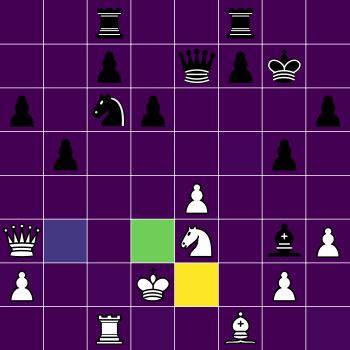

CNN Knight Probe (C1)


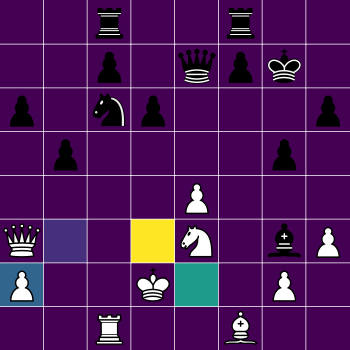

MLP Knight Probe (C1)


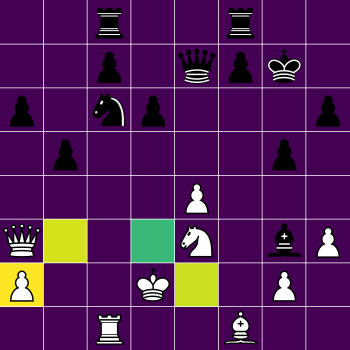


Visualizing BISHOP Probes
Analyzing legal moves for bishop at: C1
TRANSFORMER Bishop Probe (C1)


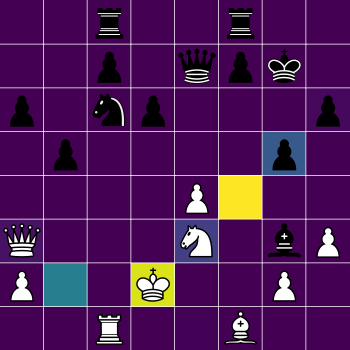

CNN Bishop Probe (C1)


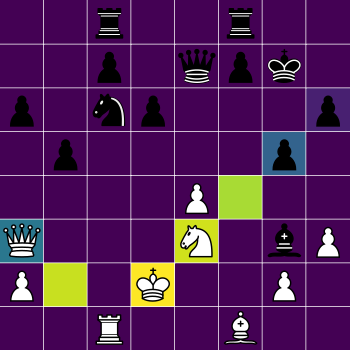

MLP Bishop Probe (C1)


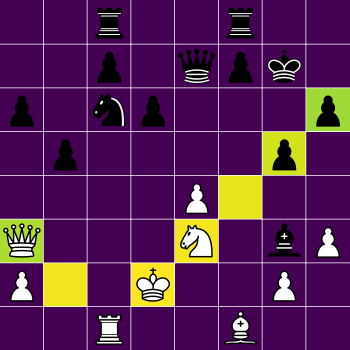


Visualizing ROOK Probes
Analyzing legal moves for rook at: C1
TRANSFORMER Rook Probe (C1)


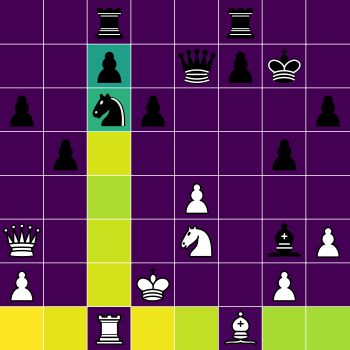

CNN Rook Probe (C1)


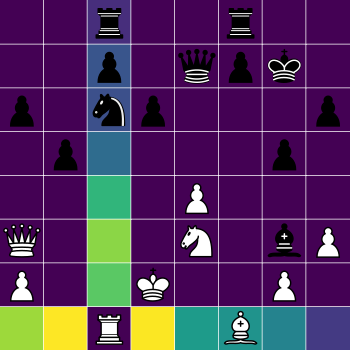

MLP Rook Probe (C1)


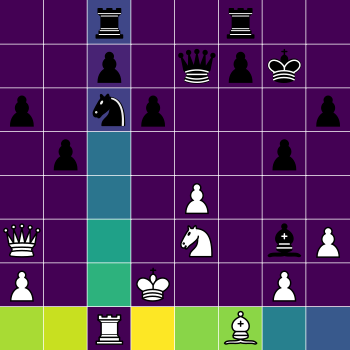


Visualizing QUEEN Probes
Analyzing legal moves for queen at: C1
TRANSFORMER Queen Probe (C1)


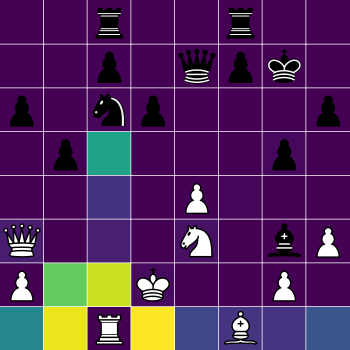

CNN Queen Probe (C1)


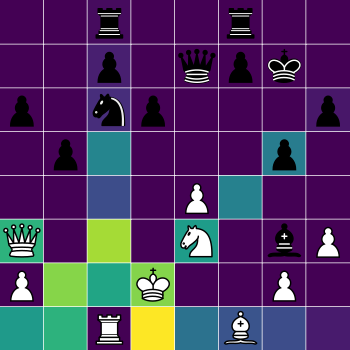

MLP Queen Probe (C1)


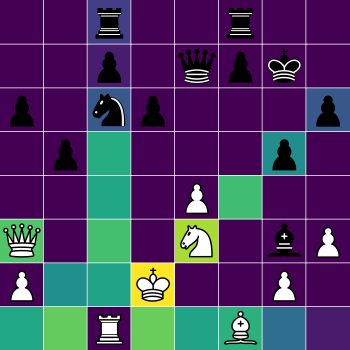

In [8]:
# ==========================================
# Forward Pass & Heatmap Visualization
# ==========================================
board = chess.Board(Config.TEST_FEN)

for current_piece in Config.PROBE_PIECES:
    piece_str = chess.piece_name(current_piece).lower()
    print(f"\n{'='*50}\nVisualizing {piece_str.upper()} Probes\n{'='*50}")

    if Config.TARGET_SQUARE is not None:
        target_square = Config.TARGET_SQUARE
    else:
        pieces = list(board.pieces(current_piece, board.turn))
        if not pieces:
            print(f"No {piece_str}s found on the board for the side to move. Skipping.")
            continue
        target_square = random.choice(pieces)

    square_name = chess.square_name(target_square)
    print(f"Analyzing legal moves for {piece_str} at: {square_name.upper()}")

    for model_key in Config.ACTIVE_PROBES:
        setup = MODEL_REGISTRY[model_key]
        if model_key == "RAW_BITMAPS":
            extractor = None
            latent_dim = 775
        else:
            model = load_model(setup, model_key) 
                
            model_path = MODEL_DIR / f"{setup['name']}.pth" 
            if not model_path.exists(): 
                print(f"\n[{model_key}] Base model not found at {model_path}. Skipping.")
                continue
                
            model.load_state_dict(torch.load(model_path))
            model.eval() 
            
            # Setup Extractor & Find Latent Dimension
            extractor = LatentExtractor(model, model_key) 
            dummy_shape = (1, 19, 8, 8) if setup['is_3d'] else (1, 775) 
            dummy_x = torch.zeros(dummy_shape).to(DEVICE) 
            latent_dim = extractor.extract(dummy_x).flatten(1).shape[1]
            
        # Load the specific probe for this piece and model
        probe_save_path = MODEL_DIR / f"{setup['name']}_{piece_str}_linear_probe_v2.pth"
        
        if not probe_save_path.exists():
            print(f"\n[{model_key}] Probe not found at {probe_save_path}. Skipping.")
            if extractor is not None: 
                extractor.remove_hook() 
            continue
            
        probe = LegalMoveProbe(latent_dim=latent_dim).to(DEVICE)
        probe.load_state_dict(torch.load(probe_save_path))
        probe.eval()
        
        # Prepare Input Tensor
        raw_tensor = fen_to_tensor(Config.TEST_FEN) if setup['is_3d'] else fen_to_vector(Config.TEST_FEN)
        x_tensor = torch.tensor(raw_tensor, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        
        # Extract Latent Vector
        if model_key == "RAW_BITMAPS":
            latent = x_tensor.flatten(1)
        else:
            latent = extractor.extract(x_tensor) 
            if latent.dim() > 2: 
                latent = latent.flatten(1) 
            
        # Prepare Query Mask (The address of the piece)
        piece_loc_mask = np.zeros(64, dtype=np.float32)
        piece_loc_mask[target_square] = 1.0
        piece_loc_tensor = torch.tensor(piece_loc_mask).unsqueeze(0).to(DEVICE)
        
        # Predict & Plot
        with torch.no_grad():
            raw_logits = probe(latent, piece_loc_tensor)
            predicted_mask_prob = torch.sigmoid(raw_logits).cpu().numpy()[0] 
            
        title = f"{model_key} {piece_str.title()} Probe ({square_name.upper()})"
        render_heatmap_svg(predicted_mask_prob, Config.TEST_FEN, title, display_svg=True)
        
        if extractor is not None:
            extractor.remove_hook() 